[Time Series Features](https://otexts.com/fpppy/04-features.html)

[Autocovariance, Autocorrelation](https://github.com/ajitsingh98/Time-Series-Analysis-and-Forecasting-with-Python/blob/master/Time_Series_Forecasting_Traditional_Methods.ipynb)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/JayitaCh/Time-Series-Analysis/blob/python/Ch4_4TS_statistics.ipynb)

# **Time Series Statistics**

## **Detecting Unusual or Anomalous Time Series**

In [1]:
!git clone -b python https://github.com/JayitaCh/Time-Series-Analysis.git

Cloning into 'Time-Series-Analysis'...
remote: Enumerating objects: 172, done.
remote: Counting objects: 100% (172/172), done.
remote: Compressing objects: 100% (142/142), done.
remote: Total 172 (delta 64), reused 98 (delta 25), pack-reused 0 (from 0)
Receiving objects: 100% (172/172), 34.51 MiB | 8.55 MiB/s, done.
Resolving deltas: 100% (64/64), done.


In [2]:
%cd Time-Series-Analysis

/content/Time-Series-Analysis


In [ ]:
!pip install -r requirements.txt

#### Load Libraries

In [73]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
np.set_printoptions(suppress=True)
np.random.seed(1)
import random
random.seed(1)
pd.set_option("max_colwidth", 100)
pd.set_option("display.precision", 3)

import seaborn as sns
sns.set_style("whitegrid")
import matplotlib.pyplot as plt
plt.style.use("ggplot")

import tsfeatures as tsf
from sklearn.decomposition import PCA
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from IPython.display import display

When we collect large amount of data, it is quite natural to obtain some ambiguous outputs at different instances of time. It is therefore important to detect such **unusual or anomalous time series**.

Such detection of unusual behaviour can be carried out by measuring different statistics. Python library `tsfeature` helps to compute a vector of features on each time series, measuring different characteristic-features of the series. The features may include **lag correlation**, the **strength of seasonality**, **spectral entropy**, etc.

<div align="center">

| Feature                 | Function                    | Description                                             |
| ----------------------- | --------------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Mean**                | `intervals`                 | Computes the mean of intervals of positive values.                                                                                                                                                             |
| **SD**                  | `intervals`                 | Computes the SD of intervals of positive values.                                                                                                                                                               |
| **ACF1**                | `acf_features`              | **Autocorrelation:** Computes the autocorrelation function for the original, first-differenced, and twice-differenced series.<br> Also gives the first ACF coefficient and sum of squares of the first 10 coefficients.                 |
| **PACF1**               | `pacf_features`             | **Partial Autocorrelation:** Computes the partial autocorrelation function for the original, first-differenced, and twice-differenced series.<br> Also gives the first PACF coefficient and sum of squares of the first 10 coefficients.        |
| **Trend**               | `stl_features`              | Obtained through STL decomposition. Trend strength is measured as<br> $$ trend = 1 - \frac{Var(e_t)}{Var(f_t + e_t)} $$                    |
| **Linearity**           | `nonlinearity`              | Measures the strength of linearity/non-linearity using the SSE ratio from nonlinear and linear autoregression.<br> Large values indicate non-linearity; values near 0 indicate linearity.<br> $$ X_2 = Tlog(\frac{SSE_1}{SSE_0}) $$                |
| **Curvature**           | `stl_features`              | Measures the strength of curvature using trend and seasonality measures from STL decomposition,<br> primarily coefficients from an orthogonal quadratic regression.                                                |
| **Season**              | `stl_features`              | Measures the strength of seasonality.<br> Values below 0 are set to 0 and values above 1 are set to 1.<br> $$ Seasonal\:strength = 1 - \frac{Var(e_t)}{Var(s_{i,t}+e_t)} $$  |
| **Periods**             | `stl_features`              | Number of periods.                                                                                                                                                                                             |
| **Peak**                | `stl_features`              | Measures the strength of peaks by giving the maximum value in the seasonal component of the STL decomposition.                                                                                                 |
| **Trough**              | `stl_features`              | Measures the strength of troughs by giving the minimum value in the seasonal component of the STL decomposition.                                                                                               |
| **Heterogeneity**       | `heterogeneity`             | Measures **autoregressive conditional heteroskedasticity** (ARCH) effects after removing mean, trend, and AR information.<br> A GARCH(1,1) model is fitted to measure changes in conditional variance over time.       |
| **Entropy**             | `count_entropy` / `entropy` | Measures spectral entropy (Shannon's entropy), which indicates the forecastability of a time series.<br> Low values indicate a high signal-to-noise ratio; high values indicate lower forecastability.             |
| **Lumpiness**           | `lumpiness`                 | Measures the **variance of the variances across tiled**, non-overlapping windows.                                                                                                                                  |
| **Stability**           | `stability`                 | Measures the **variance of the means across tiled**, non-overlapping windows.                                                                                                                                      |
| **Sparsity**            | `sparsity`                  | Computes the average number of observations with zero values.                                                                                                                                                  |
| **Spikiness**           | `stl_features`              | Measures the strength of spikiness using trend and seasonality measures from STL decomposition.                                                                                                                |
| **Arch Model Features** | `arch_stat`                 | Computes a statistic based on the Lagrange Multiplier (LM) or ARCH to analyze effects left<br> unexplained by the econometric model.                                                                               |
| **Hurst**               | `hurst`                     | Measures long-term memory in a time series and indicates the level of fractional differencing.                                                                                                                 |
| **Hol Parameters**      | `holt_parameters`           | Returns the alpha (smoothing level) and beta (smoothing slope) parameters after fitting a **Holt linear trend**<br>model.                                                                                             |
| **Hw Parameters**       | `hw_parameters`             | Represents additional seasonal components: alpha, beta, and gamma.                                                                                                                                             |
| **Fspots**              | `flat_spots`                | Divides the sample space into ten equal-sized intervals and computes the maximum run length within any single interval.                                                                                        |
| **Cpoints**             | `crossing_points`           | Counts the number of times a time series crosses its median line.                                                                                                                                              |
| **Guerrero**            | `guerrero`                  | Selects the **lambda** that minimizes the **coefficient of variation** for **subseries of x**. It uses a variance-stabilizing transformation<br> and groups observations into subseries to estimate local means and variances. |

</div>

In [74]:
household_df = pd.read_parquet('./data/hourlyblock_file_7.parquet')
household_df.head()

,timestamp,LCLid,energy_consumption,frequency,series_length,stdorToU,Acorn,Acorn_grouped,file,holidays,...,windBearing,temperature,dewPoint,pressure,apparentTemperature,windSpeed,precipType,icon,humidity,summary
0,2011-12-09 00:00:00+00:00,MAC000050,0.137,30 min,38976,Std,ACORN-D,Affluent,block_7,NO_HOLIDAY,...,267.0,7.27,1.55,1006.59,3.31,7.39,rain,clear-night,0.67,Clear
1,2011-12-09 00:30:00+00:00,MAC000050,0.113,30 min,38976,Std,ACORN-D,Affluent,block_7,NO_HOLIDAY,...,267.0,7.27,1.55,1006.59,3.31,7.39,None,None,0.67,None
2,2011-12-09 01:00:00+00:00,MAC000050,0.094,30 min,38976,Std,ACORN-D,Affluent,block_7,NO_HOLIDAY,...,261.0,6.43,1.67,1007.12,2.46,6.69,rain,clear-night,0.72,Clear
3,2011-12-09 01:30:00+00:00,MAC000050,0.066,30 min,38976,Std,ACORN-D,Affluent,block_7,NO_HOLIDAY,...,261.0,6.43,1.67,1007.12,2.46,6.69,None,None,0.72,None
4,2011-12-09 02:00:00+00:00,MAC000050,0.092,30 min,38976,Std,ACORN-D,Affluent,block_7,NO_HOLIDAY,...,257.0,6.29,0.45,1007.85,2.18,6.96,rain,clear-night,0.66,Clear


In [75]:
household_df[['precipType','icon','summary']] = household_df[['precipType','icon','summary']].ffill()

In [76]:
from src.imputation.interpolation import SeasonalInterpolation

household_df_list = []
households = household_df.LCLid.unique()

for hh in households:
  hh_filt = household_df[household_df.LCLid == hh]
  hh_imp = SeasonalInterpolation(seasonal_period=48*7).fit_transform(hh_filt.energy_consumption.values.reshape(-1,1)).squeeze()
  hh_filt['energy_consumption'] = hh_imp
  household_df_list.append(hh_filt)

household_df_imp = pd.concat(household_df_list)

In [77]:
mean_df = household_df.groupby("LCLid", as_index=False)["energy_consumption"].mean()
display(mean_df.sort_values(by="energy_consumption").head(10))

,LCLid,energy_consumption
47,MAC004814,0.039
2,MAC000073,0.084
17,MAC001370,0.087
14,MAC000776,0.091
16,MAC001135,0.094
26,MAC001826,0.115
6,MAC000289,0.137
25,MAC001825,0.145
8,MAC000619,0.162
7,MAC000317,0.164


In [11]:
hh_df_red = household_df_imp[['LCLid','timestamp','energy_consumption']].rename(columns={'LCLid':'unique_id','timestamp':'ds','energy_consumption':'y'})

In [ ]:
all_features = [
    tsf.acf_features,
    tsf.arch_stat,
    tsf.crossing_points,
    tsf.entropy,
    tsf.flat_spots,
    tsf.heterogeneity,
    tsf.holt_parameters,
    tsf.lumpiness,
    tsf.nonlinearity,
    tsf.pacf_features,
    tsf.stl_features,
    tsf.stability,
    tsf.hw_parameters,
    tsf.unitroot_kpss,
    tsf.unitroot_pp,
    tsf.series_length,
    tsf.hurst,
]

all_feat = tsf.tsfeatures(hh_df_red, freq=48, features=all_features)
all_feat.head(10)

In [78]:
all_feat = pd.read_csv('./data/all_stats.csv',index_col=0)
all_feat.head(5)

,unique_id,hurst,series_length,unitroot_pp,unitroot_kpss,hw_alpha,hw_beta,hw_gamma,stability,nperiods,...,entropy,crossing_points,arch_lm,x_acf1,x_acf10,diff1_acf1,diff1_acf10,diff2_acf1,diff2_acf10,seas_acf1
0,MAC000050,1.050,38976,-8285.976,31.510,0.578,0.0,0.024,0.179,1,...,0.618,3317,0.343,0.806,2.339,-0.209,0.055,-0.566,0.336,0.569
1,MAC000063,0.928,38928,-13237.098,6.792,0.400,0.0,0.059,0.152,1,...,0.720,7491,0.321,0.709,1.343,-0.249,0.082,-0.564,0.337,0.451
2,MAC000073,0.583,38880,-14862.884,0.624,0.716,0.0,0.000,0.116,1,...,0.885,9008,0.230,0.646,0.759,-0.122,0.072,-0.458,0.220,0.081
3,MAC000084,0.691,38880,-21984.266,1.467,0.361,0.0,0.017,0.094,1,...,0.823,7346,0.190,0.558,0.737,-0.324,0.147,-0.575,0.378,0.245
4,MAC000193,0.944,39456,-14147.812,2.977,0.389,0.0,0.068,0.112,1,...,0.731,6380,0.287,0.678,1.085,-0.208,0.066,-0.528,0.283,0.455


In [79]:
hhs_std = household_df_imp[household_df_imp.stdorToU == 'Std'].LCLid.unique()
hhs_toU = household_df_imp[household_df_imp.stdorToU == 'ToU'].LCLid.unique()

In [80]:
all_feat['tariff_category'] = np.where(all_feat.unique_id.isin(hhs_std),'Std','ToU')

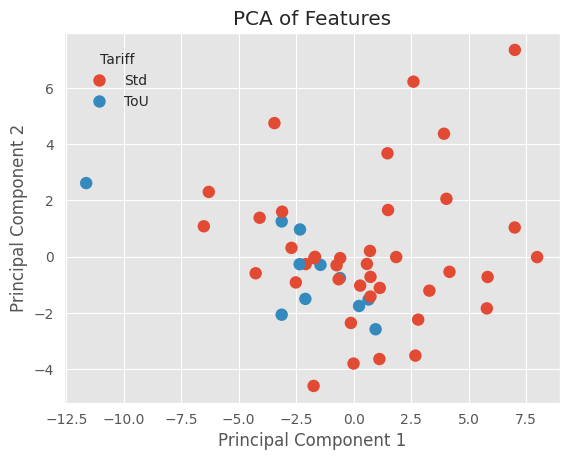

In [81]:
all_feat = all_feat.dropna(axis='columns')

X = all_feat.drop(columns=["unique_id", "tariff_category"])
pipeline = Pipeline([
    ('scale', StandardScaler()),
    ('pca', PCA(n_components=2)),
])

principal_components = pipeline.fit_transform(X)
pca_df = (
    pd.DataFrame(data=principal_components, columns=["PC1", "PC2"])
    .join(all_feat[["unique_id", "tariff_category"]])
)

fig, ax = plt.subplots()
sns.scatterplot(x="PC1", y="PC2", s=80,
    hue="tariff_category", edgecolor="none", data=pca_df, ax=ax)
ax.set(
    title="PCA of Features",
    xlabel="Principal Component 1",
    ylabel="Principal Component 2",
)
ax.get_legend().remove()
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels,
    title="Tariff", loc="upper left", ncols=1,frameon=False,
    bbox_to_anchor=(0.15, .85), borderaxespad=0)
plt.show()

Each point on the figure above represents a single **household** and its location on the plot is based on all the **37** features. The first principal component (`PC1`) is the linear combination of the features which explains the most variation in the data. The second principal component (`PC2`) is the linear combination which explains the next most variation in the data, while being uncorrelated with the first principal component.

The plot also allows us to identify **anomalous time series** — series which have unusual feature combinations. These appear as points that are separate from the majority of series in the above figure. We can identify which series they correspond to as shown in the following section.

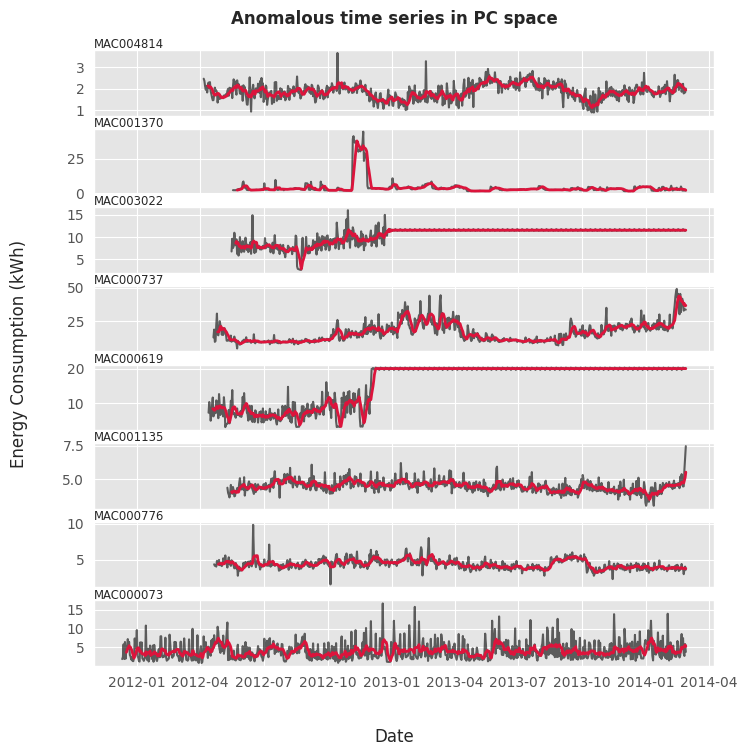

In [82]:
lof = LocalOutlierFactor(n_neighbors=10).fit(pca_df[["PC1", "PC2"]])
res = pca_df.assign(score=lof.negative_outlier_factor_)
selected_ids = res[res['score'].sort_values() < -1.8].sort_values(by='score')['unique_id']

fig, axs = plt.subplots(len(selected_ids), figsize=(8, 8), sharex=True)
for (ax, unique_id) in zip(axs, selected_ids):
    df = household_df_imp.loc[lambda x: x["LCLid"] == unique_id]
    df.index = pd.to_datetime(df["timestamp"])
    daily_energy = df['energy_consumption'].resample('D').sum()
    rolling_7d = daily_energy.rolling(window=7).mean()
    ax.plot(daily_energy.index, daily_energy, alpha=0.6, color='k', label='Daily Total')
    ax.plot(rolling_7d.index, rolling_7d, color='crimson', lw=2, label='7-Day Moving Avg')
    ax.set_title(unique_id, loc="left", size="small",y=0.9)

fig.suptitle("Anomalous time series in PC space",y=0.93,fontweight='bold')
fig.supylabel("Energy Consumption (kWh)")
fig.supxlabel("Date")
plt.show()

## **Advanced statistics in Time Series**

**Autocovariance**

We assume that the time series values we observe are the realizations of random variables $y_1,...,y_t$, which are in turn part of a larger stochastic process $\{ y_t : t \in \mathbb{Z} \}$.

In time series analysis, the analogs to the _mean_ and the _variance_ are the **mean function** and the **autocovariance function**.

The mean of a series is defined as,
$$\mu_t = E(y_t)$$

The autocovariance function is defined as,
$$\gamma(s,t) = cov(s,t) = E[(y_s-\mu_s)(y_t-\mu_t)]$$
The autocovariance measures the linear dependence between two points $(y_s,y_t)$ at different times. For smooth series the autocovariance function stays large even when the $s$ and
$t$ are far apart, whereas for choppy series the autocovariance function is close to zero for large separations.

if $s=t$ it follows that,
$$\gamma(t) = E[(y_t-\mu_t)^2] = var[y_t]$$

We can calculate a specific $\gamma_k$ as:
$$ \gamma_k = \frac{1}{n} \sum_{t=1}^{n-k}(y_t-\bar{y})(y_{t+k}-\bar{y}) $$

In [85]:
from statsmodels.tsa.stattools import acovf, acf

hh_df_filt = household_df_imp[household_df_imp.LCLid==np.random.choice(households)]

arr = acovf(hh_df_filt['energy_consumption'])

arr

array([0.35852755, 0.31224069, 0.27756873, ..., 0.00000585, 0.00000346,
       0.00000185])

Note that the number of terms in the calculations above are decreasing. Statsmodels can return an `"unbiased"` autocovariance where the estimator divides the sum of squared differences by the number of remaining data points after the lag **(N - k)** instead of the **total sample size (N)**.

**Autocorrelation**

The **autocorrelation function (ACF)** is computed from the autocovariance function by dividing by the standard deviations of $y_s$ and $y_t$.
$$ \rho(s,t) = \frac{\gamma(s,t)}{\sqrt{(\gamma(s,s)\gamma(t,t))}}$$
The autocorrelation, also called _serial correlation_, is a measure of the internal correlation of a time series. It is a representation of the degree of similarity between the time series and a lagged version of itself. High autocorrelation values mean that the **future is strongly correlated** to the past.

When working with a single variable (i.e. autocorrelation) we would consider $y_1$ to be the original series and $y_2$ a lagged version of it. Note that with autocorrelation we work with $\bar{y}$, that is, the full population mean, and not the means of the reduced set of lagged factors.

Thus, the formula for $\rho_k$ for a time series at lag $k$ is:
$$ \rho_k = \frac{\sum_{t=1}^{n-k}(y_t-\bar{y})(y_{t+k}-\bar{y})}{\sum_{t=1}^n(y_t-\bar{y})^2} $$

This can be written in terms of the covariance constant $\gamma_k$ as:
$$ \rho_k = \frac{n\gamma_k}{n\gamma_0} = \frac{\gamma_k}{\sigma^2} $$
Note that ACF values are bound by -1 and 1. That is, $-1 \leq \rho_k \leq 1$.

In [86]:
arr3 = acf(hh_df_filt['energy_consumption'])

arr3

array([1.        , 0.87089734, 0.77419081, 0.71652197, 0.64002359,
       0.56124306, 0.49649423, 0.43379303, 0.37496486, 0.32734782,
       0.28724965, 0.25277506, 0.22301495, 0.19879794, 0.17719891,
       0.15764443, 0.14095608, 0.12281582, 0.10357538, 0.08174021,
       0.06071217, 0.04373947, 0.0298905 , 0.01973645, 0.01590145,
       0.01945448, 0.02943568, 0.04390275, 0.0603593 , 0.07861237,
       0.09806631, 0.1145086 , 0.12968912, 0.14409707, 0.15809726,
       0.1758537 , 0.19479029, 0.2177101 , 0.24631281, 0.27972375,
       0.31920289, 0.36431261, 0.41277793, 0.46601723, 0.52162925,
       0.56881139])

**Partial Autocorrelation**

Partial autocorrelations measure the linear dependence of one variable after removing the effect of other variable(s) that affect both variables. That is, the partial autocorrelation at lag
$k$ is the autocorrelation between $y_t$ and $y_{t+k}$
that is not accounted for by lags 1 through $k-1$.

A common method employs the non-recursive **Yule-Walker Equations**:
$$ \phi_0 = 1; \\ \phi_1 = \rho_1; \\ \phi_2 = \frac{\rho_2-\rho_1^2}{1-\rho_1^2} = \frac{0.77 - 0.87^2}{1-0.87^2} = \frac{0.015728}{0.241537} = 0.06511
$$

As $k$ increases, we can solve for $\phi_k$ using matrix algebra and the **Levinson–Durbin recursion** algorithm which maps the sample autocorrelations $\rho$ to a Toeplitz diagonal-constant matrix.
$$
\begin{pmatrix}\rho_0&\rho_1&\cdots &\rho_{k-1}\\
\rho_1&\rho_0&\cdots &\rho_{k-2}\\
\vdots &\vdots &\ddots &\vdots \\
\rho_{k-1}&\rho_{k-2}&\cdots &\rho_0\\
\end{pmatrix}\: \begin{pmatrix}\phi_{k1}\\\phi_{k2}\\\vdots\\\phi_{kk}\end{pmatrix} \mathbf= \begin{pmatrix}\rho_1\\\rho_2\\\vdots\\\rho_k\end{pmatrix}
$$

In [92]:
from statsmodels.tsa.stattools import pacf_yw
arr4 = pacf_yw(hh_df_filt['energy_consumption'],nlags=4,method='mle')
arr4

array([ 1.        ,  0.87089734,  0.06511869,  0.1225512 , -0.07402104])

<div style="background-color: #e8f4f8; border-left: 5px solid #2980b9; padding: 12px; margin: 10px 0; border-radius: 4px;">
  <strong>NOTE:</strong> We passed in <code style="color: green;">method='mle'</code> above in order to use biased ACF coefficients. "mle" stands for "maximum likelihood estimation". Alternatively, we can pass <code>method='adjusted'</code>:
</div>

In [90]:
arr4 = pacf_yw(hh_df_filt['energy_consumption'],nlags=4,method='adjusted')
arr4

array([ 1.        ,  0.8709229 ,  0.06513452,  0.12258574, -0.07404023])

We can also use the function `pacf_ols` that provides partial autocorrelations with **ordinary least squares (OLS)** estimates for each lag instead of Yule-Walker.

In [93]:
from statsmodels.tsa.stattools import pacf_ols
arr5 = pacf_ols(hh_df_filt['energy_consumption'],nlags=4)
arr5

array([ 1.        ,  0.87090087,  0.06512453,  0.1225686 , -0.07402216])

## **Visualising advanced statistics**

The arrays returned by `.acf()` and `.pacf_yw()` show the magnitude of the autocorrelation and partial-autocorrleation respectively for a given $y$ at time $t$.

Pandas has a built-in plotting function `lag_plot` that plots increasing $y_t$ values on the horizontal axis against lagged versions of the values $y_{t+1}$ on the vertical axis. If a dataset is non-stationary with an upward trend, then neighboring values should trend in the same way.

A **Lag plot** is a scatter plot of a time series against a lag of itself. It is normally used to check for autocorrelation. If there is any pattern existing in the series, the series is autocorrelated. If there is no such pattern, the series is likely to be random white noise.

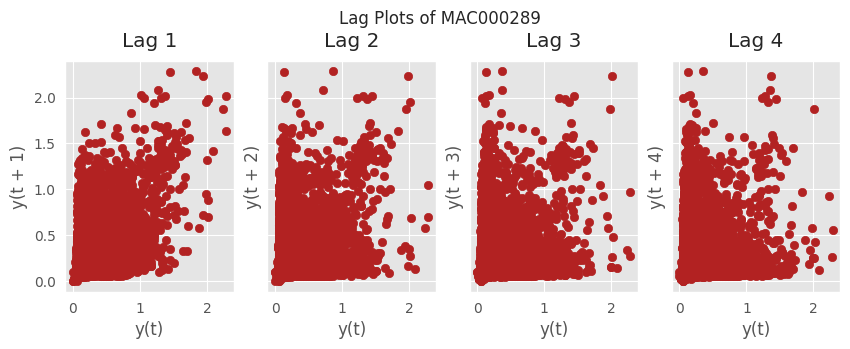

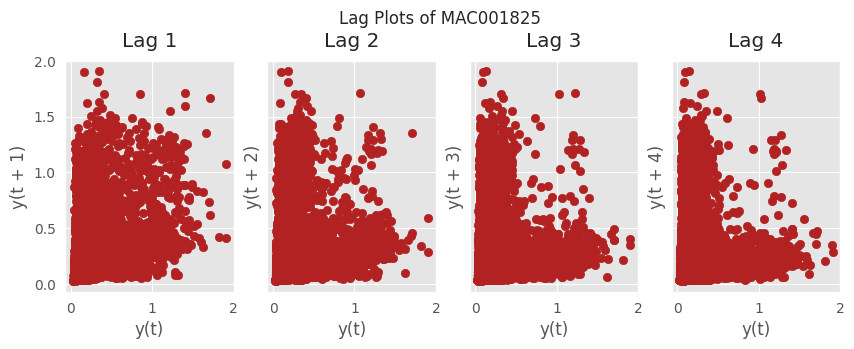

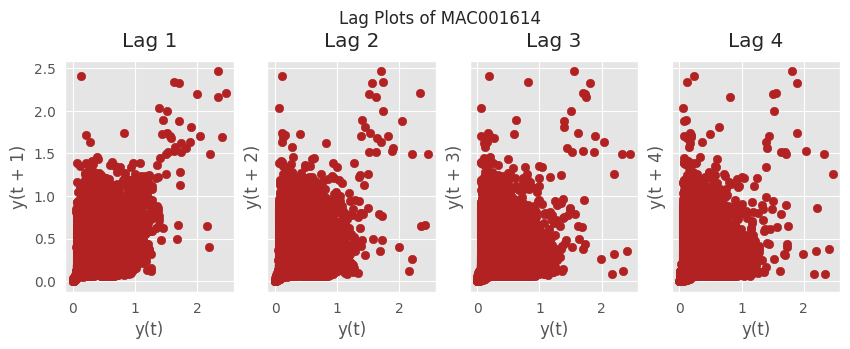

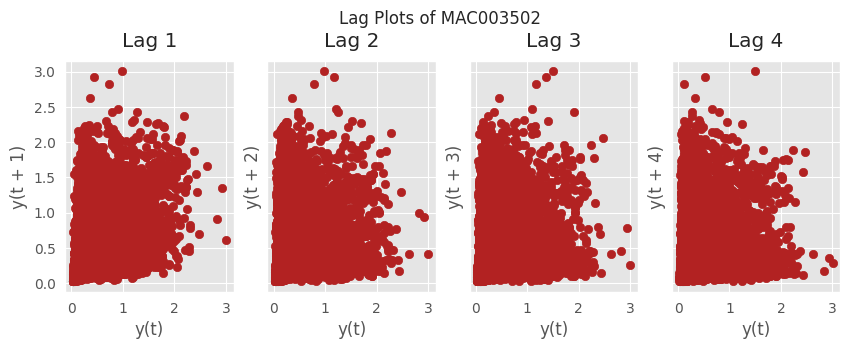

In [97]:
from pandas.plotting import lag_plot
plt.rcParams.update({'ytick.left' : False, 'axes.titlepad':10})

random_hhs = np.random.choice(households,size=4)

# Plot 1
fig, axes = plt.subplots(1, 4, figsize=(10,3), sharex=True, sharey=True, dpi=100)
for i, ax in enumerate(axes.flatten()[:4]):
    lag_plot(household_df_imp[household_df_imp.LCLid==random_hhs[0]].energy_consumption, lag=i+1, ax=ax, c='firebrick')
    ax.set_title('Lag ' + str(i+1))

fig.suptitle(f'Lag Plots of {random_hhs[0]}', y=1.05)

# Plot 2
fig, axes = plt.subplots(1, 4, figsize=(10,3), sharex=True, sharey=True, dpi=100)
for i, ax in enumerate(axes.flatten()[:4]):
    lag_plot(household_df_imp[household_df_imp.LCLid==random_hhs[1]].energy_consumption, lag=i+1, ax=ax, c='firebrick')
    ax.set_title('Lag ' + str(i+1))

fig.suptitle(f'Lag Plots of {random_hhs[1]}', y=1.05)

# Plot 3
fig, axes = plt.subplots(1, 4, figsize=(10,3), sharex=True, sharey=True, dpi=100)
for i, ax in enumerate(axes.flatten()[:4]):
    lag_plot(household_df_imp[household_df_imp.LCLid==random_hhs[2]].energy_consumption, lag=i+1, ax=ax, c='firebrick')
    ax.set_title('Lag ' + str(i+1))

fig.suptitle(f'Lag Plots of {random_hhs[2]}', y=1.05)

# Plot 4
fig, axes = plt.subplots(1, 4, figsize=(10,3), sharex=True, sharey=True, dpi=100)
for i, ax in enumerate(axes.flatten()[:4]):
    lag_plot(household_df_imp[household_df_imp.LCLid==random_hhs[3]].energy_consumption, lag=i+1, ax=ax, c='firebrick')
    ax.set_title('Lag ' + str(i+1))

fig.suptitle(f'Lag Plots of {random_hhs[3]}', y=1.05)

plt.show()

**The Correlogram**

One of the most useful descriptive tools in time series analysis is the correlogram plot which is simple a plot of the serial correlations $\hat{\rho}(k)$ versus the lag $k$ for $k = 0,1,...,M$, where $M$ is usually much less than the sample size $n$.

First, we subset the original time series and the we apply the `plot_acf()` and `plot_pacf()` function from the statsmodels package to compute and plot the autocorrelation function and partial-autocorrelation function respectively.

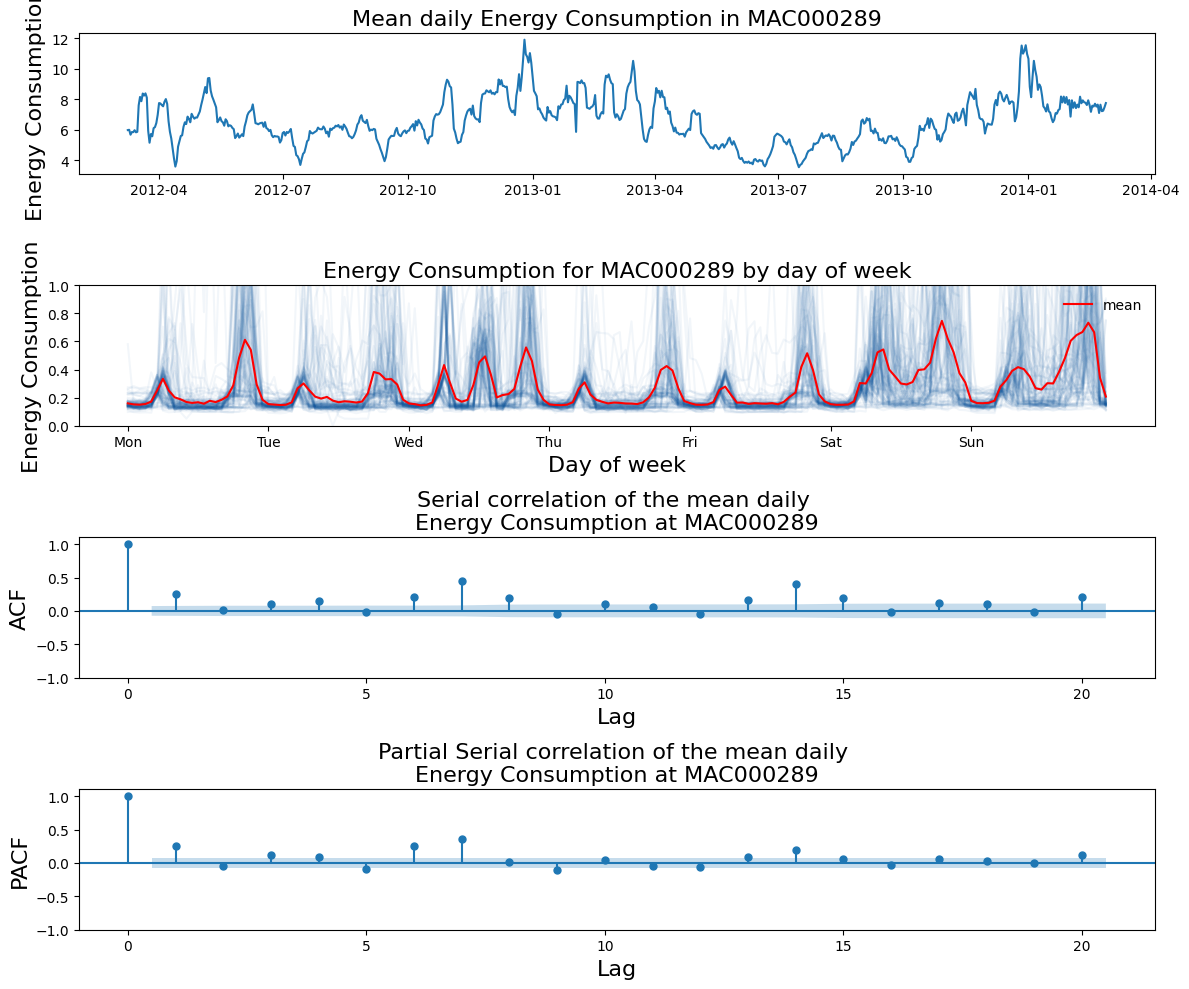

In [154]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plt.style.use('default')

hh_df_filt = household_df_imp[household_df_imp.LCLid==random_hhs[0]]
hh_df_filt = hh_df_filt.set_index('timestamp')
daily_energy = hh_df_filt['energy_consumption'].resample('D').sum()
rolling_mean_7d = daily_energy.rolling(window=7).mean()
# rolling_mean_1d = hh_df_filt['energy_consumption'].rolling(window=48).sum()
DAYS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
hourly_df = hh_df_filt.resample("H").sum()
hourly_df["week"] = hourly_df.index.to_period('W').factorize()[0]
sns_blue = sns.color_palette('Blues_r')[0]
weekly_ts =[]

fig, ax = plt.subplots(4, 1, figsize=(12, 10))

ax[0].plot(rolling_mean_7d)
ax[0].set_title(f"Mean daily Energy Consumption in {random_hhs[0]}",fontsize = 16)
ax[0].set_ylabel("Energy Consumption",fontsize = 16)

for week, ts in hourly_df.groupby("week"):
    weekly_ts.append(ts.reset_index()["energy_consumption"])
    ts.reset_index()["energy_consumption"].plot(alpha=0.05, ax=ax[1], label="_no_legend_",color=sns_blue)
    ax[1].set_xticks(ticks=np.arange(0, 167, 24), labels=DAYS)

pd.concat(weekly_ts, axis=1).mean(axis=1).plot(
    ax=ax[1], color="red", label="mean", legend=True
)
ax[1].set_ylim(0, 1)
ax[1].set_ylabel("Energy Consumption",fontsize = 16)
ax[1].set_title(f"Energy Consumption for {random_hhs[0]} by day of week",fontsize = 16)
ax[1].set_xlabel("Day of week",fontsize = 16)
ax[1].legend(loc="upper right", frameon=False)

plot_acf(daily_energy, lags=20, ax=ax[2])
ax[2].set_title(
    f"Serial correlation of the mean daily \nEnergy Consumption at {random_hhs[0]}",fontsize = 16)
ax[2].set_ylim(-1, 1.1)
ax[2].set_xlabel("Lag",fontsize = 16)
ax[2].set_ylabel("ACF",fontsize = 16)

plot_pacf(daily_energy, lags=20, ax=ax[3],
          )
ax[3].set_title(
    f"Partial Serial correlation of the mean daily \nEnergy Consumption at {random_hhs[0]}",fontsize = 16)
ax[3].set_ylim(-1, 1.1)
ax[3].set_xlabel("Lag",fontsize = 16)
ax[3].set_ylabel("PACF",fontsize = 16)

plt.tight_layout()
plt.show()

This above ACF and PACF plots represents the lags on the horizontal axis and correlations on the vertical axis. The first value $y_0$ is always 1. From the above correlogram plots, we can observe an oscillating autocorrelation structure with very strong autocorrelations at a lag of 7 and multiples of 7. This is to be expected due to the nature of the temperature time series. The blue shaded region indicate the 95% confidence limits, which comes automatically with the ACF plot. This implies:
- ACF and PACF plots show weekly seasonality ($s = 7$). The interval between the matching lags is exactly 7 days.
- **The ACF Pattern: Strong Weekly Seasonality**
  
  When the ACF repeats its shape every 7 lags, it means consumption on a given day of the week is highly correlated with consumption on that same day of the week in preceding weeks:
  - Monday's energy usage strongly predicts the next Monday's usage ($t-7$).
  - Weekend usage spikes predictably compared to weekdays.
- **The PACF Pattern: Seasonal Autoregressive Effect (SAR)**
  
  In PACF, seeing a major spike at Lag 7 that decays at Lag 14 (where $\vert \text{Lag 7} \vert{} > \vert \text{Lag 14}\vert$) indicates a **Seasonal Autoregressive** process, specifically $P = 1$ with period $s = 7$. Once we control for last week's value ($\text{Lag 7}$), the direct correlation with two weeks ago ($\text{Lag 14}$) decreases, though a residual seasonal memory remains.